# BASELINE MODEL BUILDING USING SIX DIFFERENT ALGORITHMS 

DATA MANIPUALTION, DATA VIZUALIZATION AND DATA PREPROCESSING 

In [390]:
# DATA MANIPUALTION 
import pandas as pd
import numpy as np 
import os

# DATA VIZUALIZATION 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

# ML & PREPROCESSING 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from pathlib import Path 
from tabulate import tabulate 
from joblib import dump, load 
import klib 
import xgboost as xgb


# LOADED DATASET

In [391]:
DATA_PATH = Path('shopify_sales_dataset_ml_eda.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'{DATA_PATH} not found') 
df = pd.read_csv('shopify_sales_dataset_ml_eda.csv')
print(f"LOADED DATA: {df.shape}")

LOADED DATA: (60000, 17)


In [301]:
# DATASET INITIAL SHAPE 
print('====DATASET SHAPE====')
print(df.shape)

# SHOWS FIRST 5 ROWS
print('\n====DISPLAY FIRST 5 ROWS====')
display(df.head())

# DATA INFORMATION 
print('\n====DATA INFORMATION===')
print(df.info())

====DATASET SHAPE====
(60000, 16)

====DISPLAY FIRST 5 ROWS====


,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,shipping_cost,rating,revenue,is_returned,order_year,order_month,order_day,price_per_item,discount_price
0,2.237418e+08,4352,1,20560.691925,40,1,6,444.366397,4.000000,86.029999,0.0,1970,1,1,20560.691925,8224.276770
1,7.195806e+08,12793,7,557247.305520,15,16,4,30.030400,13.690000,2538.080078,0.0,1969,12,31,34827.956595,83587.095828
2,1.402502e+09,-30111,3,410957.920470,5,25,1,127.012910,10.240000,3045.050049,0.0,1970,1,1,16438.316819,20547.896023
3,4.281175e+08,31649,5,262543.527111,0,9,4,369.408374,1.210000,1537.170044,0.0,1970,1,1,29171.503012,0.000000
4,6.066862e+08,-17815,7,172964.504284,25,9,4,622.003627,16.809999,935.760010,0.0,1970,1,1,19218.278254,43241.126071



====DATA INFORMATION===
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       60000 non-null  float64
 1   product_id        60000 non-null  int16  
 2   product_category  60000 non-null  int8   
 3   product_price     60000 non-null  float64
 4   discount_percent  60000 non-null  int8   
 5   quantity          60000 non-null  int8   
 6   customer_country  60000 non-null  int8   
 7   shipping_cost     60000 non-null  float64
 8   rating            60000 non-null  float64
 9   revenue           60000 non-null  float64
 10  is_returned       60000 non-null  float64
 11  order_year        60000 non-null  int32  
 12  order_month       60000 non-null  int32  
 13  order_day         60000 non-null  int32  
 14  price_per_item    60000 non-null  float64
 15  discount_price    60000 non-null  float64
dtypes: float64(8), int16(1), i

In [30]:
df.nunique()

order_id            60000
order_date            900
customer_id         31154
product_id           6998
product_category        8
product_price       42042
discount_percent        8
quantity                5
customer_country        7
traffic_source          5
payment_method          5
shipping_cost        2301
rating                 41
is_returned             2
discounted_price    40227
revenue             49959
profit              52478
dtype: int64

# HANDLING MISSING VALUES 

In [31]:
def handle_miss_vals(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype=='str':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())
    return df
handle_miss_vals(df)

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958.0,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0.0,86.03,86.03,64.95
1,2,2024-03-11,26825.0,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0.0,634.52,2538.08,2532.60
2,3,2025-05-10,37450.0,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0.0,609.01,3045.05,3033.78
3,4,2023-09-28,20691.0,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0.0,512.39,1537.17,1517.95
4,5,2023-04-17,24631.0,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0.0,311.92,935.76,910.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,59996,2025-04-15,11769.0,6227,Beauty,434.55,5,4,India,Direct,PayPal,5.12,3.9,0.0,412.82,1651.28,1646.16
59996,59997,2024-09-15,49939.0,5122,Fashion,397.02,5,3,UAE,Email,Apple Pay,9.91,3.6,0.0,377.17,1131.51,1121.60
59997,59998,2024-11-13,41177.0,1077,Footwear,390.80,0,4,UAE,Organic,Debit Card,16.61,4.1,0.0,390.80,1563.20,1546.59
59998,59999,2023-09-10,18973.0,7151,Beauty,365.99,40,3,UK,Paid Ads,Cash on Delivery,9.44,2.2,0.0,219.59,658.77,649.33


In [32]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_id          0
product_category    0
product_price       0
discount_percent    0
quantity            0
customer_country    0
traffic_source      0
payment_method      0
shipping_cost       0
rating              0
is_returned         0
discounted_price    0
revenue             0
profit              0
dtype: int64

# ENCODING 

In [33]:
def encodla(df, target = 'is_returned'):
    y = df[target]
    X = df.drop(target, axis=1)
   

    for col in X.columns:
        if X[col].dtype == 'str':
            if X[col].nunique()<=5:
                dummies = pd.get_dummies(X[col], prefix=col, dtype=int)
                X = pd.concat([X.drop(columns=col),dummies], axis=1)
            else:
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col])
    if y.dtype == 'str':
        le = LabelEncoder()
        y = le.fit_transform(y)

    df_encoded = pd.concat([X, pd.Series(y, name= target)], axis=1)
    return df_encoded
df_encoded = encodla(df, target='is_returned')


In [34]:
df_encoded.info()
df = df_encoded

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   order_id                         60000 non-null  int64  
 1   order_date                       60000 non-null  int64  
 2   customer_id                      60000 non-null  float64
 3   product_id                       60000 non-null  int64  
 4   product_category                 60000 non-null  int64  
 5   product_price                    60000 non-null  float64
 6   discount_percent                 60000 non-null  int64  
 7   quantity                         60000 non-null  int64  
 8   customer_country                 60000 non-null  int64  
 9   shipping_cost                    60000 non-null  float64
 10  rating                           60000 non-null  float64
 11  discounted_price                 60000 non-null  float64
 12  revenue                      

# MODEL SELECTION

In [35]:
from imblearn.over_sampling import SMOTE

# Features va target
X = df.drop('is_returned', axis=1)
y = df['is_returned']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Tekshirish
print(y_train.value_counts())

print(y_train_smote.value_counts())

is_returned
0.0    40890
1.0     7110
Name: count, dtype: int64
is_returned
0.0    40890
1.0    40890
Name: count, dtype: int64


# NOT NEED TO SCALE ALGORITHMS 


1. DECISION TREE CLASSIFIER
2. RANDOM FOREST CLASSIFIER
3. XGBOOST


In [36]:
# DECISION TREE CLASSIFIER
dt = DecisionTreeClassifier()
dt.fit(X_train_smote, y_train_smote)
y_pred_dt = dt.predict(X_test)

In [37]:
# EVALUATION METRICS
cls_report = classification_report(y_test, y_pred_dt)
cn_matrix = confusion_matrix(y_test, y_pred_dt)

# PRINT THE EVALUATION
print(f'===Classification Report===')
print(cls_report)
print(f'\n===Confusion Matrix===')
print(cn_matrix)

===Classification Report===
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.84     10223
         1.0       0.16      0.19      0.17      1777

    accuracy                           0.73     12000
   macro avg       0.51      0.51      0.51     12000
weighted avg       0.75      0.73      0.74     12000


===Confusion Matrix===
[[8417 1806]
 [1439  338]]


In [38]:
# RANDOM FOREST CLASSIFIER
rf = RandomForestClassifier()
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test)

In [39]:
# EVALUATION METRICS
cls_report = classification_report(y_test, y_pred_rf)
cn_matrix = confusion_matrix(y_test, y_pred_rf)

# PRINT THE EVALUATION
print(f'===Classification Report===')
print(cls_report)
print(f'\n===Confusion Matrix===')
print(cn_matrix)

===Classification Report===
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92     10223
         1.0       0.50      0.00      0.00      1777

    accuracy                           0.85     12000
   macro avg       0.68      0.50      0.46     12000
weighted avg       0.80      0.85      0.78     12000


===Confusion Matrix===
[[10222     1]
 [ 1776     1]]


In [40]:
# XGBOOST 
xgb_class = xgb.XGBClassifier(
    n_estimators = 100,
    learning_rate=0.01,
    max_depth = 3, 
    subsample=1,
    colsample_bytree=0.8,
    random_state=9
)
xgb_class.fit(X_train_smote, y_train_smote)
y_pred_xgb_class = xgb_class.predict(X_test)

In [41]:
# EVALUATION METRICS
cls_report = classification_report(y_test, y_pred_xgb_class)
cn_matrix = confusion_matrix(y_test, y_pred_xgb_class)

# PRINT THE EVALUATION
print(f'===Classification Report===')
print(cls_report)
print(f'\n===Confusion Matrix===')
print(cn_matrix)

===Classification Report===
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92     10223
         1.0       0.00      0.00      0.00      1777

    accuracy                           0.85     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.85      0.78     12000


===Confusion Matrix===
[[10223     0]
 [ 1777     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

# SHOULD BE SCLAED ALGORITHMS 

In [42]:
# LOGISTIC REGRESSION 

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_smote_scaled, y_train_smote)
y_pred_lr = lr.predict(X_test_scaled)

In [43]:
# EVALUATION METRICS
cls_report = classification_report(y_test, y_pred_lr)
cn_matrix = confusion_matrix(y_test, y_pred_lr)

# PRINT THE EVALUATION
print(f'===Classification Report===')
print(cls_report)
print(f'\n===Confusion Matrix===')
print(cn_matrix)

===Classification Report===
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92     10223
         1.0       0.00      0.00      0.00      1777

    accuracy                           0.85     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.85      0.78     12000


===Confusion Matrix===
[[10223     0]
 [ 1777     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [44]:
# SUPPORT VECTOR MACHINE 
svc = SVC(kernel='rbf', C=1.0, max_iter=10000)
svc.fit(X_train_smote_scaled, y_train_smote)
y_pred_svc = svc.predict(X_test_scaled)

/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [45]:
# EVALUATION METRICS
cls_report = classification_report(y_test, y_pred_svc)
cn_matrix = confusion_matrix(y_test, y_pred_svc)

# PRINT THE EVALUATION
print(f'===Classification Report===')
print(cls_report)
print(f'\n===Confusion Matrix===')
print(cn_matrix)

===Classification Report===
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92     10223
         1.0       0.00      0.00      0.00      1777

    accuracy                           0.85     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.85      0.78     12000


===Confusion Matrix===
[[10223     0]
 [ 1777     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [46]:
# KNN
knn = KNeighborsClassifier()
knn.fit(X_train_smote_scaled, y_train_smote)
y_pred_knn = knn.predict(X_test_scaled)

In [47]:
# EVALUATION METRICS
cls_report = classification_report(y_test, y_pred_knn)
cn_matrix = confusion_matrix(y_test, y_pred_knn)

# PRINT THE EVALUATION
print(f'===Classification Report===')
print(cls_report)
print(f'\n===Confusion Matrix===')
print(cn_matrix)

===Classification Report===
              precision    recall  f1-score   support

         0.0       0.85      0.94      0.90     10223
         1.0       0.15      0.06      0.09      1777

    accuracy                           0.81     12000
   macro avg       0.50      0.50      0.49     12000
weighted avg       0.75      0.81      0.78     12000


===Confusion Matrix===
[[9634  589]
 [1670  107]]


# SHOW THE RESULS ON THE TABULATE


In [48]:
from tabulate import tabulate

results_baseline = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.85],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.81]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


In [49]:
best_score = max(model[1] for model in results_baseline)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in results_baseline:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['Random Forest Classifier', 'XGBClassifier','Logistic Regression', 'Support Vector Machine']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'Best model: {model[0]}, best accuracy is: {model[1]} which is 85%')

Best model: Random Forest Classifier, best accuracy is: 0.85 which is 85%
Best model: XGBClassifier, best accuracy is: 0.85 which is 85%
Best model: Logistic Regression, best accuracy is: 0.85 which is 85%
Best model: Support Vector Machine, best accuracy is: 0.85 which is 85%


# IMPROVED MODEL BUILDING

In [392]:
# DATA PREPOCESSNING
class DataPreprocessing:
    def __init__(self, df):
        self.df = df

    def encodla(self, target='is_returned'):
        self.df = df
        self.target = target

        y = self.df[target]
        X = self.df.drop(target, axis=1)

        for col in X.columns:
            if X[col].dtype == 'str':
                if X[col].nunique() <=5:
                    dummies = pd.get_dummies(X[col], prefix=col, dtype=int)
                    X = pd.concat([X.drop(columns=col), dummies], axis=1)
                else:
                    le = LabelEncoder()
                    X[col] = le.fit_transform(X[col])
        
        if y.dtype == 'str':
            le = LabelEncoder()
            y = le.fit_transform(y)
        self.df = pd.concat([X, pd.Series(y, name=target)], axis=1)
        return self
processor = DataPreprocessing(df)
df_ready = (
    processor
    .encodla()
    .df
)
print(f"Data After Preprocessing: {df_ready.shape}")


    




Data After Preprocessing: (60000, 25)


In [393]:
df = df_ready

In [394]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   order_id                         60000 non-null  int64  
 1   order_date                       60000 non-null  int64  
 2   customer_id                      59999 non-null  float64
 3   product_id                       60000 non-null  int64  
 4   product_category                 60000 non-null  int64  
 5   product_price                    59999 non-null  float64
 6   discount_percent                 60000 non-null  int64  
 7   quantity                         60000 non-null  int64  
 8   customer_country                 60000 non-null  int64  
 9   shipping_cost                    59996 non-null  float64
 10  rating                           59996 non-null  float64
 11  discounted_price                 59994 non-null  float64
 12  revenue                      

Shape of cleaned data: (60000, 25) - Remaining NAs: 24


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 8.35 MB (-72.99%)



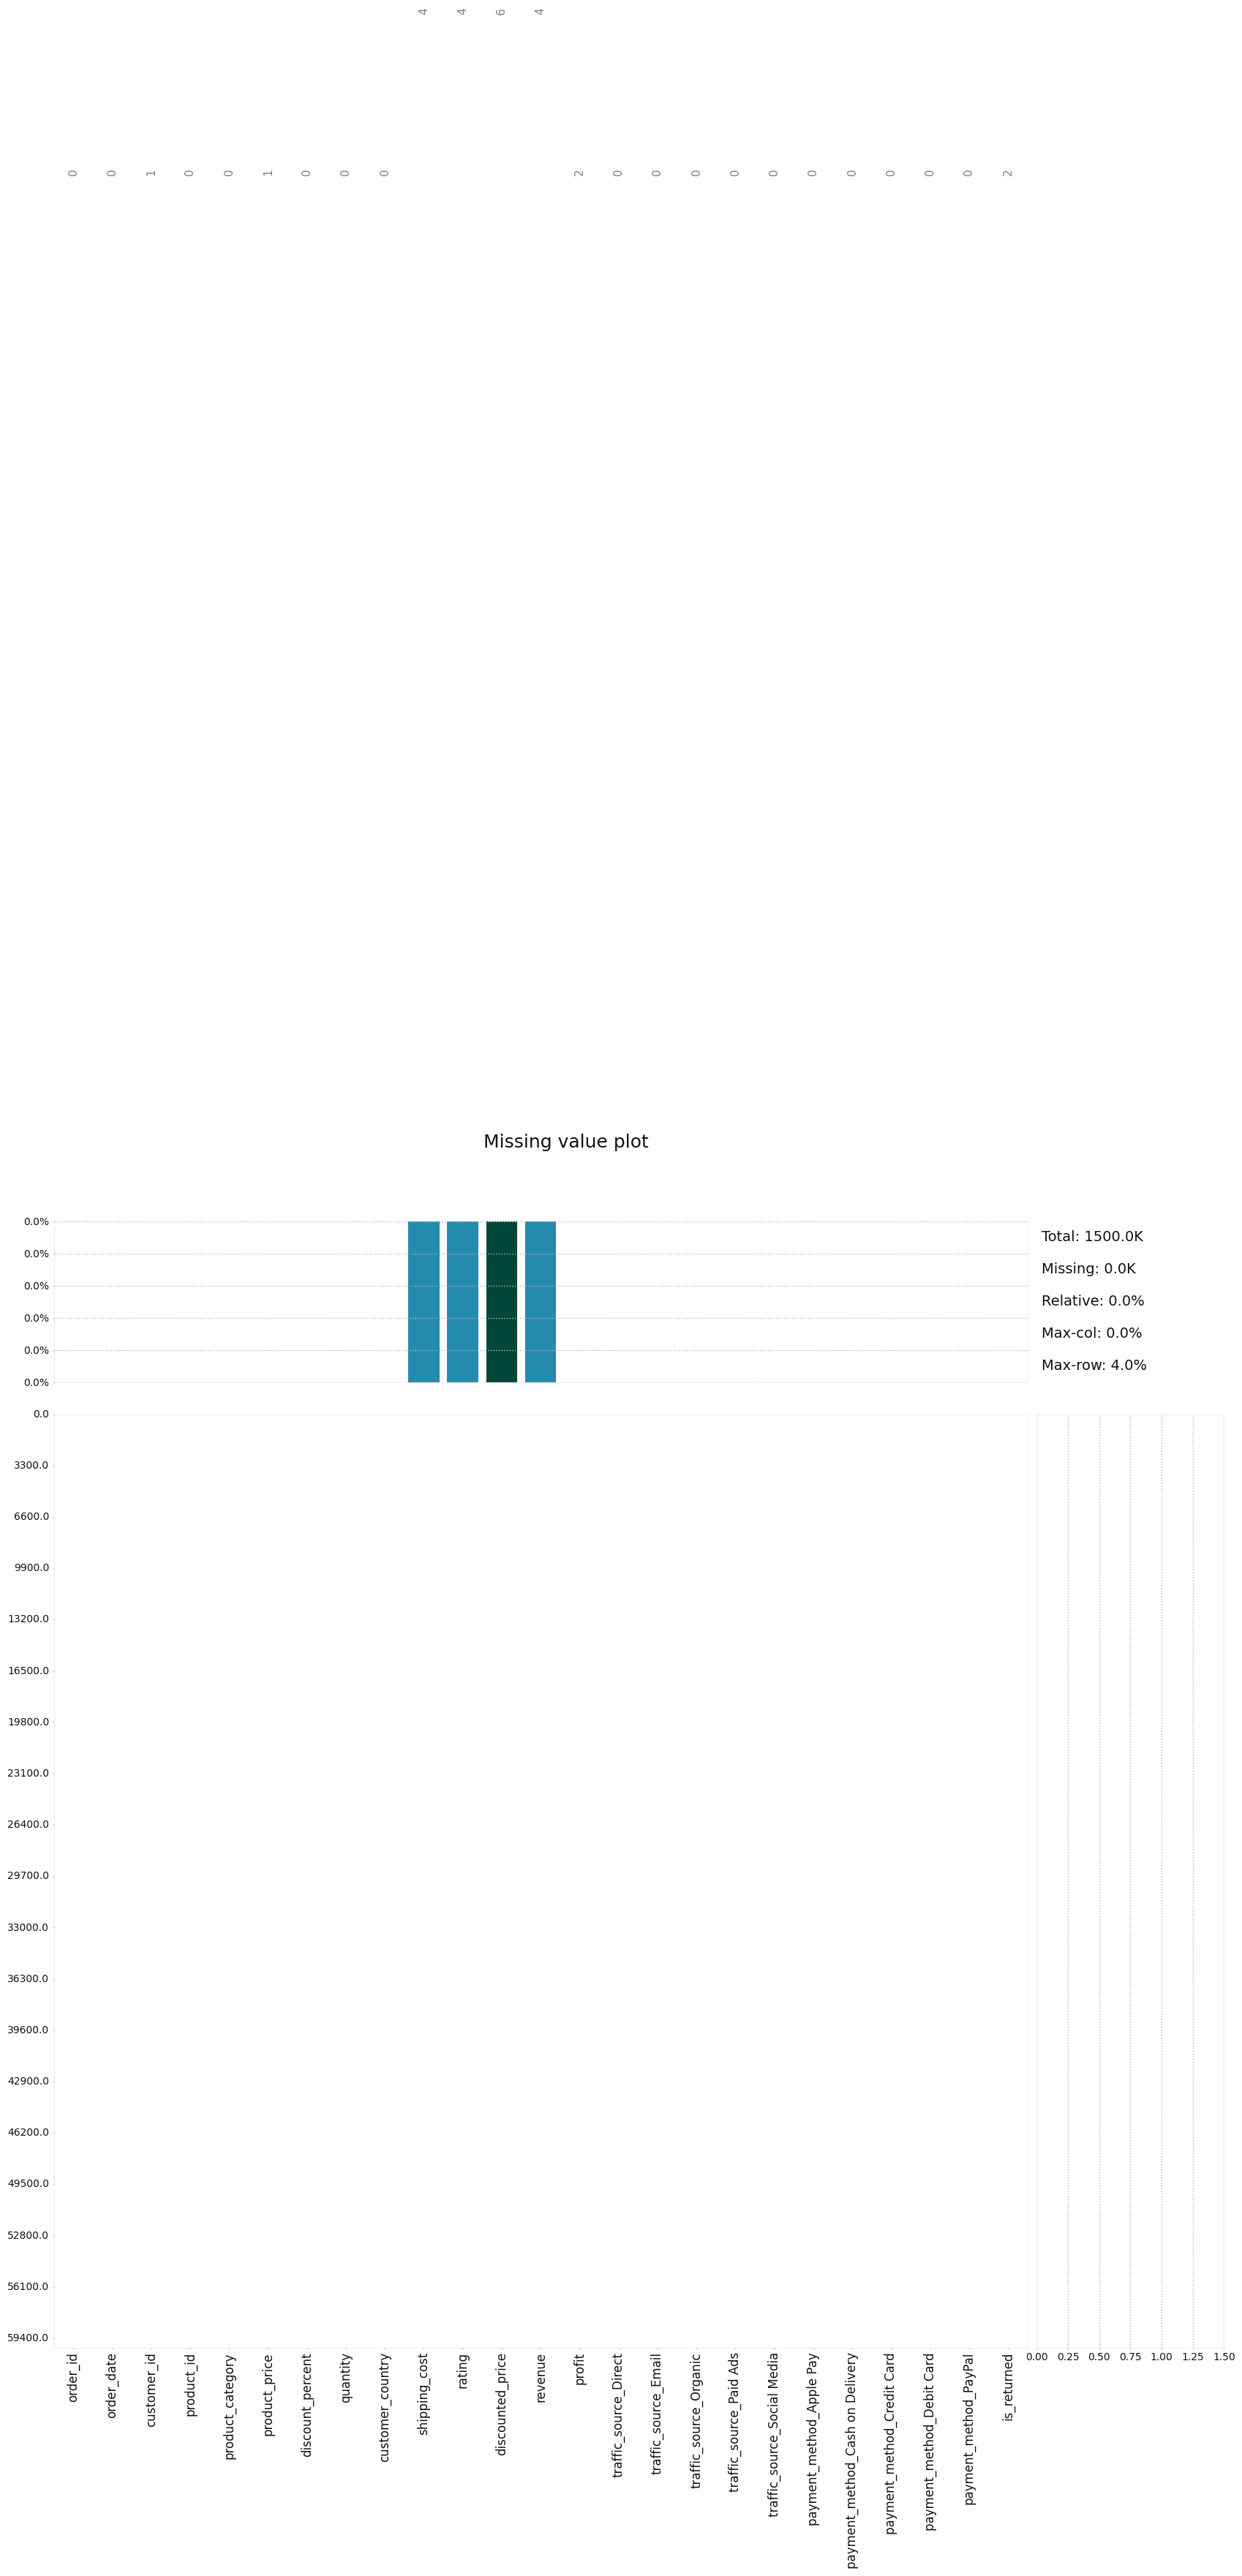

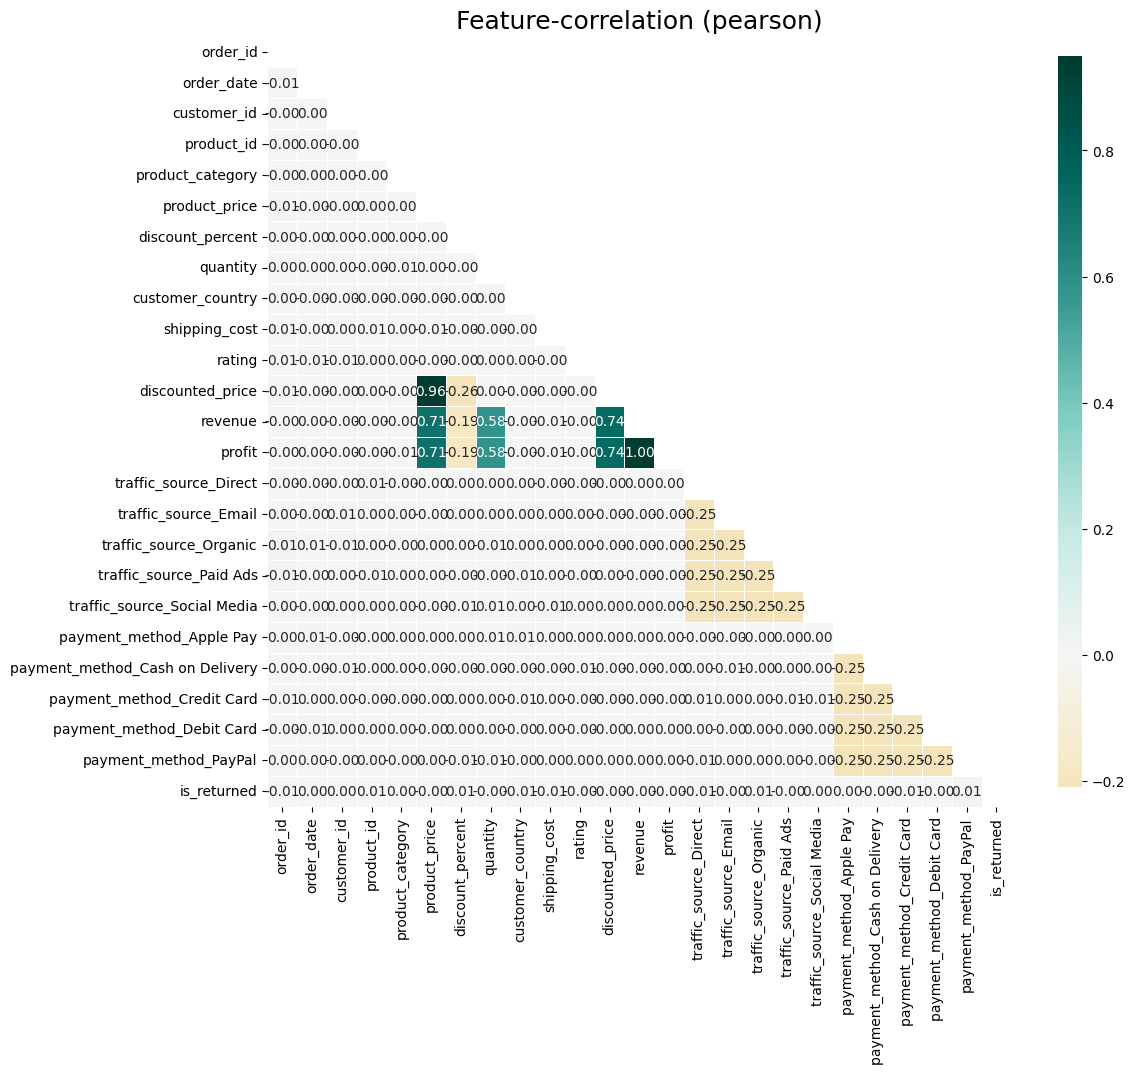

In [395]:
# KLIB MISSING VALUES 
klib.missingval_plot(df)

# KLIB CORRELATION PLOT
klib.corr_plot(df)

# KLIB DATA CLEANING 
df_clean = klib.data_cleaning(df, drop_duplicates=True)

In [347]:
df_clean.info()
df = df_clean

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   order_id                         60000 non-null  int32  
 1   order_date                       60000 non-null  int16  
 2   customer_id                      59999 non-null  float32
 3   product_id                       60000 non-null  int16  
 4   product_category                 60000 non-null  int8   
 5   product_price                    59999 non-null  float32
 6   discount_percent                 60000 non-null  int8   
 7   quantity                         60000 non-null  int8   
 8   customer_country                 60000 non-null  int8   
 9   shipping_cost                    59996 non-null  float32
 10  rating                           59996 non-null  float32
 11  discounted_price                 59994 non-null  float32
 12  revenue                      

# HERE WE CAN SEE THE ADVANCED MISSING VALUE TREATMENT

PREDICTIVE (MODEL-BASED) IMPUTATION 

In [396]:
from sklearn.ensemble import RandomForestRegressor

for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue

    train = df[df[col].notnull()]
    test = df[df[col].isnull()]

    X_train = train.drop(col, axis=1)
    y_train = train[col]

    X_test = test.drop(col, axis=1)
    
    model = RandomForestRegressor(n_estimators=100,n_jobs=-1, max_depth=10, min_samples_leaf=5)
    model.fit(X_train, y_train)
    df[col] = df[col].astype('float64')

    # PREDICTED MISSING VALUES 
    df.loc[df[col].isnull(), col] = model.predict(X_test)

In [397]:
df.isna().sum()

order_id                           0
order_date                         0
customer_id                        0
product_id                         0
product_category                   0
product_price                      0
discount_percent                   0
quantity                           0
customer_country                   0
shipping_cost                      0
rating                             0
discounted_price                   0
revenue                            0
profit                             0
traffic_source_Direct              0
traffic_source_Email               0
traffic_source_Organic             0
traffic_source_Paid Ads            0
traffic_source_Social Media        0
payment_method_Apple Pay           0
payment_method_Cash on Delivery    0
payment_method_Credit Card         0
payment_method_Debit Card          0
payment_method_PayPal              0
is_returned                        0
dtype: int64

# FEATURE ENGINEERING & SELECTION

TRANSFORM FEATURES

In [ ]:
# num_cols = df.select_dtypes(include=[np.number])
# skewness = num_cols.skew()

# log_transformation = skewness[(skewness>=0.5)].index.tolist()
# print("Log transformation columns: ", log_transformation)
# print(skewness)

Log transformation columns:  ['revenue', 'profit', 'traffic_source_direct', 'traffic_source_email', 'traffic_source_organic', 'traffic_source_paid_ads', 'traffic_source_social_media', 'payment_method_apple_pay', 'payment_method_cash_on_delivery', 'payment_method_credit_card', 'payment_method_debit_card', 'payment_method_pay_pal', 'is_returned']
order_id                           0.000000
order_date                        -0.001253
customer_id                       -0.001813
product_id                        -0.006634
product_category                   0.005343
product_price                     -0.009052
discount_percent                   0.234573
quantity                          -0.004972
customer_country                   0.008680
shipping_cost                     -0.005069
rating                            -0.000027
discounted_price                   0.198202
revenue                            1.017041
profit                             1.016862
traffic_source_direct              1.

In [ ]:
# 

# log_cols = [
#     'revenue', 
#     'profit', 
#     'traffic_source_direct', 
#     'traffic_source_email', 
#     'traffic_source_organic', 
#     'traffic_source_paid_ads', 
#     'traffic_source_social_media', 
#     'payment_method_apple_pay', 
#     'payment_method_cash_on_delivery', 
#     'payment_method_credit_card', 
#     'payment_method_debit_card', 
#     'payment_method_pay_pal', 
# ]

# for col in log_cols:
#     df[col + '_log'] = np.log1p(df[col])
# df = df.drop(log_cols, axis=1)

/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# num_cols = df.select_dtypes(include=[np.number])
# skewness = num_cols.skew()
# print(skewness)

order_id                               0.000000
order_date                            -0.001253
customer_id                           -0.001813
product_id                            -0.006634
product_category                       0.005343
product_price                         -0.009052
discount_percent                       0.234573
quantity                              -0.004972
customer_country                       0.008680
shipping_cost                         -0.005069
rating                                -0.000027
discounted_price                       0.198202
is_returned                            1.981265
revenue_log                           -0.938445
profit_log                            -1.245087
traffic_source_direct_log                   inf
traffic_source_email_log                    inf
traffic_source_organic_log                  inf
traffic_source_paid_ads_log                 inf
traffic_source_social_media_log             inf
payment_method_apple_pay_log            

/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1291: RuntimeWarning: overflow encountered in scalar multiply
  result = (count * (count - 1) ** 0.5 / (count - 2)) * (m3 / m2**1.5)


In [ ]:
# df.replace([np.inf, -np.inf], np.nan, inplace=True)

/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,shipping_cost,...,traffic_source_direct_log,traffic_source_email_log,traffic_source_organic_log,traffic_source_paid_ads_log,traffic_source_social_media_log,payment_method_apple_pay_log,payment_method_cash_on_delivery_log,payment_method_credit_card_log,payment_method_debit_card_log,payment_method_pay_pal_log
0,1,102,14958.0,7824,1,143.389999,40,1,6,21.080000,...,0.000000,0.000000,0.000000,0.693359,0.000000,0.000000,0.000000,0.693359,0.000000,0.000000
1,2,435,26825.0,5557,7,746.489990,15,4,4,5.480000,...,0.000000,0.693359,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693359
2,3,860,37450.0,2225,3,641.059998,5,5,1,11.270000,...,0.000000,0.000000,0.000000,0.693359,0.000000,0.693359,0.000000,0.000000,0.000000,0.000000
3,4,270,20691.0,7855,5,512.390015,0,3,4,19.219999,...,0.693359,0.000000,0.000000,0.000000,0.000000,0.693359,0.000000,0.000000,0.000000,0.000000
4,5,106,24631.0,7789,7,415.890015,25,3,4,24.940001,...,0.000000,0.000000,0.000000,0.000000,0.693359,0.000000,0.000000,0.000000,0.693359,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,59996,835,11769.0,6227,2,434.549988,5,4,3,5.120000,...,0.693359,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693359
59996,59997,623,49939.0,5122,4,397.019989,5,3,4,9.910000,...,0.000000,0.693359,0.000000,0.000000,0.000000,0.693359,0.000000,0.000000,0.000000,0.000000
59997,59998,682,41177.0,1077,5,390.799988,0,4,4,16.610001,...,0.000000,0.000000,0.693359,0.000000,0.000000,0.000000,0.000000,0.000000,0.693359,0.000000
59998,59999,252,18973.0,7151,2,365.989990,40,3,5,9.440000,...,0.000000,0.000000,0.000000,0.693359,0.000000,0.000000,0.693359,0.000000,0.000000,0.000000


In [310]:
np.isinf(df).sum()

customer_id         0
product_id          0
product_category    0
product_price       0
discount_percent    0
quantity            0
customer_country    0
shipping_cost       0
rating              0
revenue             0
order_year          0
order_month         0
order_day           0
price_per_item      0
discount_price      0
is_returned         0
dtype: int64

In [398]:
# NEWGATIVE TRANSFORMATION: SQUARED METHOD
num_cols = df.select_dtypes(include=[np.number])
skewness = num_cols.skew()
neg_cols = skewness[(skewness<0)].index.tolist()
print("Negative Transformation Columns: ", neg_cols)
print(skewness)


Negative Transformation Columns:  ['order_date', 'customer_id', 'product_id', 'product_price', 'quantity', 'shipping_cost', 'rating']
order_id                           0.000000
order_date                        -0.001253
customer_id                       -0.001812
product_id                        -0.006634
product_category                   0.005343
product_price                     -0.009052
discount_percent                   0.234573
quantity                          -0.004972
customer_country                   0.008680
shipping_cost                     -0.005069
rating                            -0.000027
discounted_price                   0.198202
revenue                            1.017041
profit                             1.016862
traffic_source_Direct              1.505386
traffic_source_Email               1.510231
traffic_source_Organic             1.490435
traffic_source_Paid Ads            1.497696
traffic_source_Social Media        1.497436
payment_method_Apple Pay      

In [399]:
neg_cols = ['order_date', 'customer_id', 'product_id', 'product_price', 'quantity', 'shipping_cost', 'rating']


for col in neg_cols:
    if col in df.columns:
        df[col] = df[col] ** 2
print(skewness)

order_id                           0.000000
order_date                        -0.001253
customer_id                       -0.001812
product_id                        -0.006634
product_category                   0.005343
product_price                     -0.009052
discount_percent                   0.234573
quantity                          -0.004972
customer_country                   0.008680
shipping_cost                     -0.005069
rating                            -0.000027
discounted_price                   0.198202
revenue                            1.017041
profit                             1.016862
traffic_source_Direct              1.505386
traffic_source_Email               1.510231
traffic_source_Organic             1.490435
traffic_source_Paid Ads            1.497696
traffic_source_Social Media        1.497436
payment_method_Apple Pay           1.485014
payment_method_Cash on Delivery    1.496137
payment_method_Credit Card         1.500428
payment_method_Debit Card       

In [400]:
num_cols = df.select_dtypes(include=[np.number])
skewness = num_cols.skew()
print(skewness)

order_id                           0.000000
order_date                         0.640157
customer_id                        0.444078
product_id                         0.504813
product_category                   0.005343
product_price                      0.617736
discount_percent                   0.234573
quantity                           0.463001
customer_country                   0.008680
shipping_cost                      0.552334
rating                             0.449064
discounted_price                   0.198202
revenue                            1.017041
profit                             1.016862
traffic_source_Direct              1.505386
traffic_source_Email               1.510231
traffic_source_Organic             1.490435
traffic_source_Paid Ads            1.497696
traffic_source_Social Media        1.497436
payment_method_Apple Pay           1.485014
payment_method_Cash on Delivery    1.496137
payment_method_Credit Card         1.500428
payment_method_Debit Card       

In [401]:
# FEATURE SELECTION 
X = df.drop('is_returned', axis=1)
y = df['is_returned']

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col]>0.8)]

X_filtered = X.drop(columns=to_drop)
df_filtered = pd.concat([X_filtered, y], axis=1)

print('Dropped Columns: ', to_drop)
print('Original Shape: ', df.shape)
print("Filtered Shape: ", df_filtered.shape)


Dropped Columns:  ['discounted_price', 'profit']
Original Shape:  (60000, 25)
Filtered Shape:  (60000, 23)


In [402]:
# HIGH CORR PAIRS 
high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] is not np.nan and upper.loc[row, col] > 0.8:
            high_corr_pairs.append([row, col, round(upper.loc[row, col], 2)])
corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print('Highly correlated feature pairs (correlation > 0.8): ')
print(corr_table)


Highly correlated feature pairs (correlation > 0.8): 
       Feature 1         Feature 2  Correlation
0  product_price  discounted_price         0.93
1        revenue            profit         1.00


# CREATING A HEATMAP TO DISPLAY CORRELATIONS BETWEEN VARIABLES


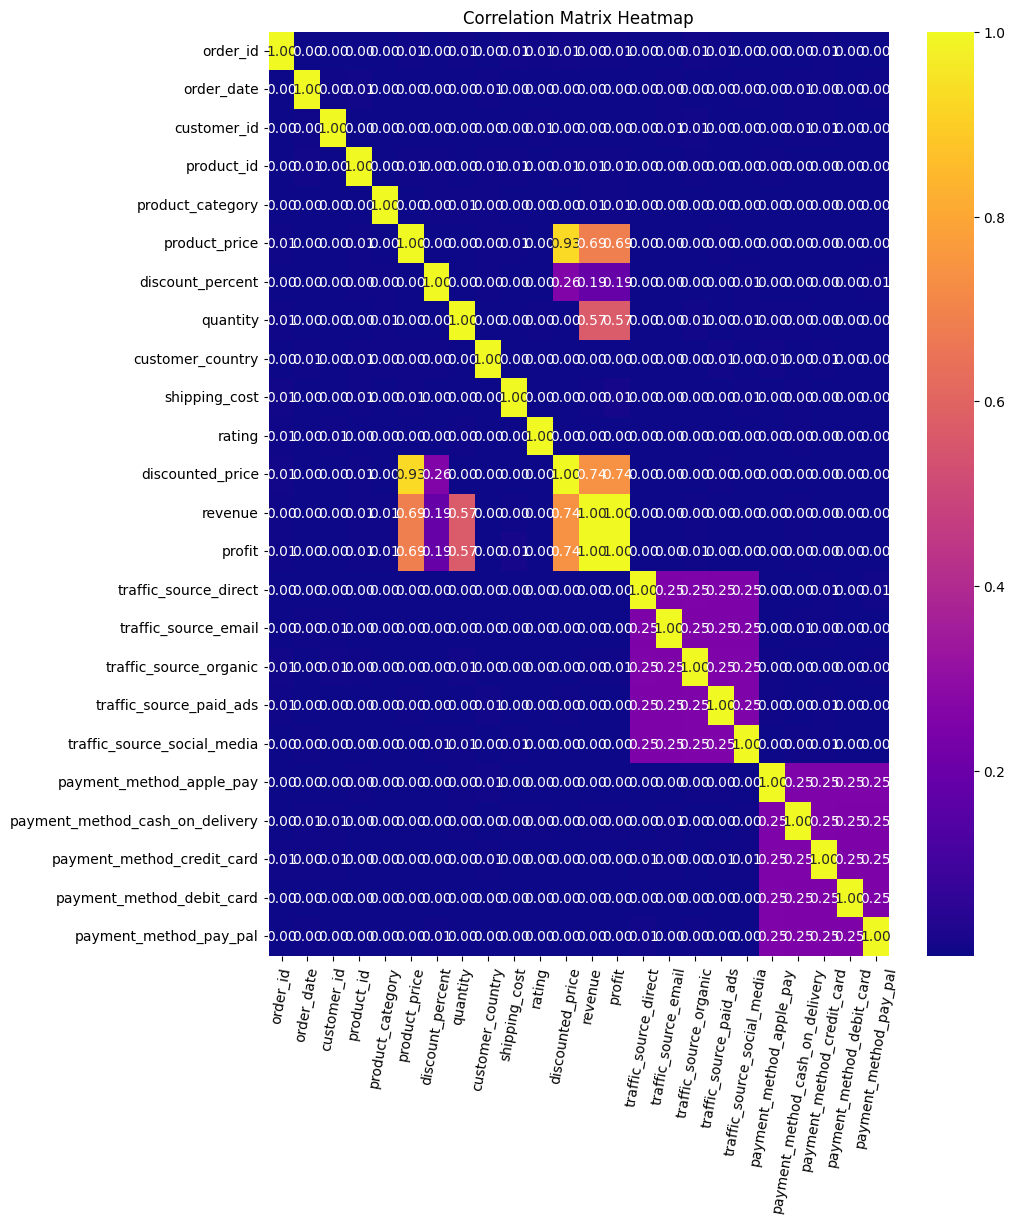

In [355]:
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='plasma', cbar=True)
plt.xticks(rotation=80)
plt.title('Correlation Matrix Heatmap')
plt.show()

# LOW VARIANCE 

In [403]:
from sklearn.feature_selection import VarianceThreshold

X = df_filtered.drop('is_returned', axis=1)
y = df_filtered['is_returned']

threshold = 0.2
selector = VarianceThreshold(threshold=threshold)
selector.fit(X)

low_variance_features = X.columns[~selector.get_support()]
print("Low variance to drop: ")
print(list(low_variance_features))

X_filtered = X.drop(columns=low_variance_features)
df_final = pd.concat([X_filtered, y], axis=1)
print("Original Shape: ", df_filtered.shape)
print("New Filtered Shape: ", df_final.shape)


Low variance to drop: 
['traffic_source_Direct', 'traffic_source_Email', 'traffic_source_Organic', 'traffic_source_Paid Ads', 'traffic_source_Social Media', 'payment_method_Apple Pay', 'payment_method_Cash on Delivery', 'payment_method_Credit Card', 'payment_method_Debit Card', 'payment_method_PayPal']
Original Shape:  (60000, 23)
New Filtered Shape:  (60000, 13)


In [404]:
df = df_final 

In [405]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  int64  
 2   customer_id       60000 non-null  float64
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  int64  
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  int64  
 9   shipping_cost     60000 non-null  float64
 10  rating            60000 non-null  float64
 11  revenue           60000 non-null  float64
 12  is_returned       60000 non-null  float64
dtypes: float64(6), int64(7)
memory usage: 6.0 MB


In [406]:
# ADVANCED NEW FEATURE CREATIION 

# df['order_date'] = pd.to_datetime(df['order_date'])

# df['order_year'] = df['order_date'].dt.year
# df['order_month'] = df['order_date'].dt.month 
# df['order_day'] = df['order_date'].dt.day

df['price_per_item'] = df['product_price'] / df['quantity']
df['discount_price'] = df["product_price"] * df['discount_percent'] / 100




In [407]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  int64  
 2   customer_id       60000 non-null  float64
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  int64  
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  int64  
 9   shipping_cost     60000 non-null  float64
 10  rating            60000 non-null  float64
 11  revenue           60000 non-null  float64
 12  is_returned       60000 non-null  float64
 13  price_per_item    60000 non-null  float64
 14  discount_price    60000 non-null  float64
dtypes: float64(8), int64(7)
memory usage: 6.9 MB


In [408]:

df = df.drop('order_date', axis=1)

In [409]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   customer_id       60000 non-null  float64
 2   product_id        60000 non-null  int64  
 3   product_category  60000 non-null  int64  
 4   product_price     60000 non-null  float64
 5   discount_percent  60000 non-null  int64  
 6   quantity          60000 non-null  int64  
 7   customer_country  60000 non-null  int64  
 8   shipping_cost     60000 non-null  float64
 9   rating            60000 non-null  float64
 10  revenue           60000 non-null  float64
 11  is_returned       60000 non-null  float64
 12  price_per_item    60000 non-null  float64
 13  discount_price    60000 non-null  float64
dtypes: float64(8), int64(6)
memory usage: 6.4 MB


# METHOD 1 ===> CORRELATION FILTERING + MUTUTAL INFORMATION <===

In [170]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd 

corr = df.corr()['is_returned'].sort_values(ascending=False)

X = df.drop('is_returned', axis=1)
y = df['is_returned'].astype(int)

mi = mutual_info_classif(X, y, random_state=42)

mi_series = pd.Series(mi, index=X.columns).sort_values()

print('Correlation Ranking:\n', corr)
print('\nMutual Information Ranking:\n', mi_series)


Correlation Ranking:
 is_returned                        1.000000
traffic_source_Organic             0.010834
payment_method_PayPal              0.009977
discount_percent                   0.006538
product_id                         0.005585
customer_id                        0.001797
discount_price                     0.001377
traffic_source_Social Media        0.001260
product_category                   0.001205
payment_method_Apple Pay           0.000742
rating                            -0.000276
quantity                          -0.001703
payment_method_Debit Card         -0.001997
traffic_source_Paid Ads           -0.002360
revenue                           -0.003020
traffic_source_Email              -0.003028
payment_method_Cash on Delivery   -0.003133
product_price                     -0.003431
price_per_item                    -0.004538
payment_method_Credit Card        -0.005516
shipping_cost                     -0.006278
traffic_source_Direct             -0.006624
customer_c

In [173]:
# FILTERING GREATER THAN 0.001 
selected_features = mi_series[mi_series > 0.001].index.tolist()

# CREATING NEW X_TRAIN
X_selected = X[selected_features]

print(f"Number of selecting features: {len(selected_features)}")
print(f"Columns: {selected_features}")

Number of selecting features: 12
Columns: ['shipping_cost', 'customer_country', 'traffic_source_Email', 'traffic_source_Social Media', 'traffic_source_Organic', 'product_category', 'payment_method_Cash on Delivery', 'rating', 'quantity', 'order_year', 'order_day', 'order_month']


# ALGORITHMS

NO NEED TO SCALE:
1. DECISION TREE CLASSIFIER
2. RANDOM FOREST CLASSIFIER
3. XGBOOST CLASSIFIER


In [ ]:
# DECISION TREE CLASSIFIER 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import classification_report, confusion_matrix

X_mi = X[[
    'shipping_cost', 
    'customer_country', 
    'traffic_source_Email', 
    'traffic_source_Social Media', 
    'traffic_source_Organic', 
    'product_category', 
    'payment_method_Cash on Delivery', 
    'rating', 'quantity', 
    'order_year', 
    'order_day', 
    'order_month'
]]
X_train, X_test, y_train, y_test = train_test_split(X_mi, y, test_size=0.3, random_state=9)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


In [190]:
# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_dt)
conf_matrix = confusion_matrix(y_test, y_pred_dt)
print("\n Classificaion Report: Decision Tree Classifier ")
print(class_report)
print("Confusion Matrix: ")
print(conf_matrix)


 Classificaion Report: Decision Tree Classifier 
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     15334
           1       0.14      0.16      0.15      2666

    accuracy                           0.73     18000
   macro avg       0.50      0.50      0.50     18000
weighted avg       0.75      0.73      0.74     18000

Confusion Matrix: 
[[12749  2585]
 [ 2240   426]]


In [191]:
# RANDOM FOREST 
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred_rf)
print("\n Classificaion Report: Random Forest Classifier")
print(class_report)
print("Confusion Matrix: ")
print(conf_matrix)


 Classificaion Report: Random Forest Classifier
              precision    recall  f1-score   support

           0       0.85      0.99      0.91     15334
           1       0.12      0.01      0.02      2666

    accuracy                           0.84     18000
   macro avg       0.49      0.50      0.47     18000
weighted avg       0.74      0.84      0.78     18000

Confusion Matrix: 
[[15137   197]
 [ 2638    28]]


In [192]:
# XGBOOST  
import xgboost
xgb_class = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=3,
    subsample = 1,
    colsample_bytree = 0.8,
    random_state=9
)
xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_xgb_class)
conf_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print("\n Classificaion Report:XGBoost Classifier ")
print(class_report)
print("Confusion Matrix: ")
print(conf_matrix)


 Classificaion Report:XGBoost Classifier 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     15334
           1       0.00      0.00      0.00      2666

    accuracy                           0.85     18000
   macro avg       0.43      0.50      0.46     18000
weighted avg       0.73      0.85      0.78     18000

Confusion Matrix: 
[[15334     0]
 [ 2666     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

NEED TO BE SCALED ALOGIRTHMS:
1. LOGISTIC REGRESSION 
2. SUPPORT VECTOR MACHINE CLASSIFIER
3. K NEAREST NEIGHBORS 


In [184]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [193]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_lr)
conf_matrix = confusion_matrix(y_test, y_pred_lr)
print("\n Classificaion Report: Logistic Regression")
print(class_report)
print("Confusion Matrix: ")
print(conf_matrix)


 Classificaion Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     15334
           1       0.00      0.00      0.00      2666

    accuracy                           0.85     18000
   macro avg       0.43      0.50      0.46     18000
weighted avg       0.73      0.85      0.78     18000

Confusion Matrix: 
[[15334     0]
 [ 2666     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [194]:
# SVC
from sklearn.svm import SVC

svc = SVC(kernel='linear', C=1.0)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_svc)
conf_matrix = confusion_matrix(y_test, y_pred_svc)
print("\n Classificaion Report: Support Vector Machine Classifier")
print(class_report)
print("Confusion Matrix: ")
print(conf_matrix)



 Classificaion Report: Support Vector Machine Classifier
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     15334
           1       0.00      0.00      0.00      2666

    accuracy                           0.85     18000
   macro avg       0.43      0.50      0.46     18000
weighted avg       0.73      0.85      0.78     18000

Confusion Matrix: 
[[15334     0]
 [ 2666     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [195]:
# KNN 
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_knn)
conf_matrix = confusion_matrix(y_test, y_pred_knn)
print("\n Classificaion Report: ")
print(class_report)
print("Confusion Matrix: K Nearest Neighbors")
print(conf_matrix)



 Classificaion Report: 
              precision    recall  f1-score   support

           0       0.85      0.98      0.91     15334
           1       0.16      0.03      0.05      2666

    accuracy                           0.83     18000
   macro avg       0.50      0.50      0.48     18000
weighted avg       0.75      0.83      0.78     18000

Confusion Matrix: K Nearest Neighbors
[[14951   383]
 [ 2595    71]]


In [189]:
# TABULATE BASELINE
from tabulate import tabulate

results_baseline = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.85],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.81]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')



+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


In [197]:
# TABULATE IMPROVED 
from tabulate import tabulate

results_mi_fs = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.84],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.83]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


# DIFFERENCE BETWEEN BASELINE AND MI FS

In [198]:
baseline_dict = {row[0]: row[1] for row in results_baseline}
comparison_results = []

for model_name, mi_accuracy in results_mi_fs:
    baseline_accuracy = baseline_dict.get(model_name, 0)
    diff = mi_accuracy - baseline_accuracy
    
    # IF STATEMENT RELATED TO THE DIFFERENCE 
    if diff > 0:
        status = f"+{diff:.2f} 🟢 improved"
    elif diff < 0:
        status = f"{diff:.2f} 🔴 decreased"
    else:
        status = "0.00 ⚪️ stayed stable"
    
    comparison_results.append([model_name, baseline_accuracy, mi_accuracy, status])

# CALLING TABLE
headers = ['Models', 'Baseline Acc', 'MI FS Acc', 'Difference / Status']
table = tabulate(comparison_results, headers=headers, tablefmt='grid', floatfmt='.2f')

print('\n====================== FEATURE SELECTION COMPARISON ========================')
print(table)
print('============================================================================')


====================== FEATURE SELECTION COMPARISON ========================
+--------------------------+----------------+-------------+-----------------------+
| Models                   |   Baseline Acc |   MI FS Acc | Difference / Status   |
+==========================+================+=============+=======================+
| Decision Tree Classifier |           0.73 |        0.73 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-------------+-----------------------+
| Random Forest Classifier |           0.85 |        0.84 | -0.01 🔴 decreased    |
+--------------------------+----------------+-------------+-----------------------+
| XGBClassifier            |           0.85 |        0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-------------+-----------------------+
| Logistic Regression      |           0.85 |        0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-------------+-----------------------+

HERE WE CAN SEE ONLY KNN HAS BEEN DEVELOPED BY 0.02%. HOWEVER, OTHERS STAYED STABLE REGARDING TO RANDOM FOREST CLASSIFIER WHICH HAS BEEN DECLINED TO -0.01%.

# METHOD 2 ===> ANOVA F-TEST (CATEGORICAL => CONTINUOUS TARGET ) <===

In [255]:
from sklearn.feature_selection import f_classif
import pandas as pd

f_values, p_values = f_classif(X, y)

f_df = pd.DataFrame({
    'Feature':X.columns,
    'F_value': f_values,
    'P_value': p_values
})

f_df = f_df.sort_values('F_value', ascending=True)

print(f_df) 

# F---value -> higher is beter
# P---value -> lower is better 

top_k = 10 # threshold amount
selected_features = f_df.head(top_k)['Feature'].tolist()
print(selected_features)

                            Feature   F_value   P_value
1                       customer_id  0.177693  0.911566
16         payment_method_apple_pay  0.179727  0.910202
19        payment_method_debit_card  0.245205  0.864796
14          traffic_source_paid_ads  0.278304  0.841099
6                          quantity  0.297777  0.827037
9                            rating  0.423325  0.736275
18       payment_method_credit_card  0.774983  0.507763
0                        order_date  0.849872  0.466397
3                  product_category  0.864043  0.458877
10                          revenue  0.928778  0.425761
5                  discount_percent  1.017427  0.383642
11            traffic_source_direct  1.043125  0.372113
2                        product_id  1.062364  0.363677
8                     shipping_cost  1.187058  0.312924
15      traffic_source_social_media  1.445710  0.227298
17  payment_method_cash_on_delivery  1.609420  0.184826
12             traffic_source_email  1.610400  0

In [256]:
X_anova = X[[
    'customer_id', 
    'payment_method_apple_pay', 
    'payment_method_debit_card', 
    'traffic_source_paid_ads', 
    'quantity', 
    'rating', 
    'payment_method_credit_card', 
    'order_date', 
    'product_category', 
    'revenue'
]]

X_train, X_test, y_train, y_test = train_test_split(
    X_anova, y, test_size=0.4, random_state=42
)


# MODEL TRAINING: ANOVA F-TEST (CATEGORICAL -> CONTINUOUS TARGET) AFTER APPLYING FOR FE + FS


# ALGORITHMS:


NO NEED TO SCALE:
1. DECISION TREE CLASSIFIER
2. RANDOM FOREST CLASSIFIER
3. XGBOOST CLASSIFIER

In [258]:
X = df.drop('is_returned', axis=1)
y = df['is_returned'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_anova, y, test_size=0.4, random_state=42
)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_dt)
conf_matrix = confusion_matrix(y_test, y_pred_dt)
print("\n Classificaion Report: ")
print(class_report)
print("Confusion Matrix: Decision Tree Classifier")
print(conf_matrix)


 Classificaion Report: 
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     20500
           1       0.14      0.17      0.16      3500

    accuracy                           0.73     24000
   macro avg       0.50      0.50      0.50     24000
weighted avg       0.75      0.73      0.74     24000

Confusion Matrix: Decision Tree Classifier
[[16946  3554]
 [ 2904   596]]


In [260]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred_rf)
print("\n Classificaion Report:Random Forest Classifier ")
print(class_report)
print("Confusion Matrix: Random Forest Classifier")
print(conf_matrix)


 Classificaion Report:Random Forest Classifier 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     20500
           1       0.00      0.00      0.00      3500

    accuracy                           0.85     24000
   macro avg       0.43      0.50      0.46     24000
weighted avg       0.73      0.85      0.79     24000

Confusion Matrix: Random Forest Classifier
[[20497     3]
 [ 3500     0]]


In [261]:
xgb_class = xgb.XGBClassifier()
xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_xgb_class)
conf_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print("\n Classificaion Report:XGBoost Classifier ")
print(class_report)
print("Confusion Matrix: XGBoost Classifier")
print(conf_matrix)


 Classificaion Report:XGBoost Classifier 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     20500
           1       0.22      0.00      0.01      3500

    accuracy                           0.85     24000
   macro avg       0.54      0.50      0.46     24000
weighted avg       0.76      0.85      0.79     24000

Confusion Matrix: XGBoost Classifier
[[20450    50]
 [ 3486    14]]


# ALGORITHMS

NO NEED TO BE SCALED:
1. LOGISTIC REGRESSION 
2. SVM
3. KNN

In [265]:
# LOGISTIC REGRESSION 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_lr)
conf_matrix = confusion_matrix(y_test, y_pred_lr)
print("\n Classificaion Report: Logistic Regression ")
print(class_report)
print("Confusion Matrix: Logistic Regression")
print(conf_matrix)


 Classificaion Report: Logistic Regression 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     20500
           1       0.00      0.00      0.00      3500

    accuracy                           0.85     24000
   macro avg       0.43      0.50      0.46     24000
weighted avg       0.73      0.85      0.79     24000

Confusion Matrix: Logistic Regression
[[20500     0]
 [ 3500     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [266]:
# SUPPORT VECTOR MACHINE  
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_svm)
conf_matrix = confusion_matrix(y_test, y_pred_svm)
print("\n Classificaion Report: SVM ")
print(class_report)
print("Confusion Matrix: SVM")
print(conf_matrix)


 Classificaion Report: SVM 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     20500
           1       0.00      0.00      0.00      3500

    accuracy                           0.85     24000
   macro avg       0.43      0.50      0.46     24000
weighted avg       0.73      0.85      0.79     24000

Confusion Matrix: SVM
[[20500     0]
 [ 3500     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [267]:
# KNN  
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_knn)
conf_matrix = confusion_matrix(y_test, y_pred_knn)
print("\n Classificaion Report: KNN ")
print(class_report)
print("Confusion Matrix: KNN")
print(conf_matrix)


 Classificaion Report: KNN 
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     20500
           1       0.14      0.03      0.04      3500

    accuracy                           0.83     24000
   macro avg       0.50      0.50      0.48     24000
weighted avg       0.75      0.83      0.78     24000

Confusion Matrix: KNN
[[19947   553]
 [ 3409    91]]


In [269]:
# TABULATE BASELINE
from tabulate import tabulate

results_baseline = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.85],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.81]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')




+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


In [271]:
# TABULATE IMPROVED 
from tabulate import tabulate

results_anova = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.85],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.83]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


In [272]:
baseline_dict = {row[0]: row[1] for row in results_baseline}
comparison_results = []

for model_name, mi_accuracy in results_anova:
    baseline_accuracy = baseline_dict.get(model_name, 0)
    diff = mi_accuracy - baseline_accuracy
    
    # IF STATEMENT RELATED TO THE DIFFERENCE 
    if diff > 0:
        status = f"+{diff:.2f} 🟢 improved"
    elif diff < 0:
        status = f"{diff:.2f} 🔴 decreased"
    else:
        status = "0.00 ⚪️ stayed stable"
    
    comparison_results.append([model_name, baseline_accuracy, mi_accuracy, status])

# CALLING TABLE
headers = ['Models', 'Baseline Acc', 'MI FS Acc', 'Difference / Status']
table = tabulate(comparison_results, headers=headers, tablefmt='grid', floatfmt='.2f')

print('\n====================== FEATURE SELECTION COMPARISON ========================')
print(table)
print('============================================================================')




====================== FEATURE SELECTION COMPARISON ========================
+--------------------------+----------------+-------------+-----------------------+
| Models                   |   Baseline Acc |   MI FS Acc | Difference / Status   |
+==========================+================+=============+=======================+
| Decision Tree Classifier |           0.73 |        0.73 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-------------+-----------------------+
| Random Forest Classifier |           0.85 |        0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-------------+-----------------------+
| XGBClassifier            |           0.85 |        0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-------------+-----------------------+
| Logistic Regression      |           0.85 |        0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-------------+-----------------------

HERE WE CAN SEE ONLY KNN HAS BEEN DEVELOPED BY 0.02% AND OTHERS STAYED STABLE ONLY.

# METHOD 3 ===> L1 (LASSO) REGULARIZATION <===

In [415]:
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

X = df.drop('is_returned', axis=1)
y = df['is_returned'].astype(int)

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(penalty='l1', solver='liblinear'))
])
lasso.fit(X, y)

coef = lasso.named_steps['model'].coef_[0]
lasso_df = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':coef
})
lasso_df['Importance'] = lasso_df['Coefficient'].abs()
lasso_df = lasso_df.sort_values('Importance', ascending=False)
print("===LASSO FEATURE IMPORTANCE (HIGH->LOW)===")
print(lasso_df)

===LASSO FEATURE IMPORTANCE (HIGH->LOW)===
             Feature  Coefficient  Importance
7   customer_country    -0.022669    0.022669
11    price_per_item    -0.017796    0.017796
8      shipping_cost    -0.017538    0.017538
5   discount_percent     0.016964    0.016964
0           order_id    -0.015827    0.015827
2         product_id     0.015646    0.015646
6           quantity    -0.014279    0.014279
4      product_price    -0.005695    0.005695
1        customer_id     0.004814    0.004814
12    discount_price     0.003323    0.003323
3   product_category     0.003018    0.003018
10           revenue     0.002791    0.002791
9             rating    -0.000331    0.000331


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [418]:
X = df.drop(['is_returned', 'order_id', 'customer_id', 'product_id'], axis=1)
y = df['is_returned'].astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# MODEL TRAINING: LASSO (L1-REGULARIZATION) AFTER APPLYING FOR FE + FS


NO NEED TO SCALE:
1. DECISION TREE CLASSIFIER
2. RANDOM FOREST CLASSIFIER
3. XGBOOST CLASSIFIER


In [419]:
# DECISION TREE CLASSIFIER 
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_dt)
conf_matrix = confusion_matrix(y_test, y_pred_dt)
print("\n Classificaion Report: Decision Tree Classifier ")
print(class_report)
print("Confusion Matrix: Decision Tree Classifier")
print(conf_matrix)


 Classificaion Report: Decision Tree Classifier 
              precision    recall  f1-score   support

           0       0.86      0.83      0.84     10267
           1       0.15      0.17      0.16      1733

    accuracy                           0.73     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       0.75      0.73      0.74     12000

Confusion Matrix: Decision Tree Classifier
[[8524 1743]
 [1437  296]]


In [420]:
# RANDOM FOREST CLASSIFIER 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# METRICS OF rf AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred_rf)
print("\n Classificaion Report: Random Forest Classifier ")
print(class_report)
print("Confusion Matrix: Random Forest Classifier")
print(conf_matrix)


 Classificaion Report: Random Forest Classifier 
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     10267
           1       0.22      0.00      0.00      1733

    accuracy                           0.86     12000
   macro avg       0.54      0.50      0.46     12000
weighted avg       0.76      0.86      0.79     12000

Confusion Matrix: Random Forest Classifier
[[10260     7]
 [ 1731     2]]


In [423]:
# XGBOOST CLASSIFIER
import xgboost as xgb

xgb_class = xgb.XGBClassifier(
    n_estimators=150, 
    learning_rate = 0.1,
    max_depth=5, 
    subsample=1,
    colsample_bytree=0.8,
    random_forest=9
)
xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

# METRICS OF xgb_class AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_xgb_class)
conf_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print("\n Classificaion Report: XGBoost Classifier ")
print(class_report)
print("Confusion Matrix: XGBoost Classifier")
print(conf_matrix)

/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:44:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "random_forest" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Classificaion Report: XGBoost Classifier 
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     10267
           1       0.00      0.00      0.00      1733

    accuracy                           0.86     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.86      0.79     12000

Confusion Matrix: XGBoost Classifier
[[10267     0]
 [ 1733     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [424]:
# LOGISTIC REGRESSION 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_lr)
conf_matrix = confusion_matrix(y_test, y_pred_lr)
print("\n Classificaion Report:Logistic Regression ")
print(class_report)
print("Confusion Matrix: Logistic Regression")
print(conf_matrix)




 Classificaion Report:Logistic Regression 
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     10267
           1       0.00      0.00      0.00      1733

    accuracy                           0.86     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.86      0.79     12000

Confusion Matrix: Logistic Regression
[[10267     0]
 [ 1733     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [425]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf', C=1.0)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_svc)
conf_matrix = confusion_matrix(y_test, y_pred_svc)
print("\n Classificaion Report:Support Vector Machine ")
print(class_report)
print("Confusion Matrix: Support Vector Machine")
print(conf_matrix)


 Classificaion Report:Support Vector Machine 
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     10267
           1       0.00      0.00      0.00      1733

    accuracy                           0.86     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.86      0.79     12000

Confusion Matrix: Support Vector Machine
[[10267     0]
 [ 1733     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [426]:
# KNN 
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_knn)
conf_matrix = confusion_matrix(y_test, y_pred_knn)
print("\n Classificaion Report: ")
print(class_report)
print("Confusion Matrix: K Nearest Neighbors")
print(conf_matrix)


 Classificaion Report: 
              precision    recall  f1-score   support

           0       0.86      0.98      0.91     10267
           1       0.14      0.02      0.04      1733

    accuracy                           0.84     12000
   macro avg       0.50      0.50      0.48     12000
weighted avg       0.75      0.84      0.79     12000

Confusion Matrix: K Nearest Neighbors
[[10012   255]
 [ 1691    42]]


In [427]:
# TABULATE BASELINE
from tabulate import tabulate

results_baseline = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.85],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.81]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')




+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


In [431]:
# TABULATE IMPROVED 
from tabulate import tabulate

results_lasso = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.86],
    ['XGBClassifier',0.86],
    ['Logistic Regression',0.86],
    ['Support Vector Machine',0.86],
    ['KNN', 0.84]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_lasso, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.86 |
+--------------------------+------------+
| XGBClassifier            |       0.86 |
+--------------------------+------------+
| Logistic Regression      |       0.86 |
+--------------------------+------------+
| Support Vector Machine   |       0.86 |
+--------------------------+------------+
| KNN                      |       0.84 |
+--------------------------+------------+


In [434]:
baseline_dict = {row[0]: row[1] for row in results_baseline}
comparison_results = []

for model_name, lasso_accuracy in results_lasso:
    baseline_accuracy = baseline_dict.get(model_name, 0)
    diff = lasso_accuracy - baseline_accuracy
    
    # IF STATEMENT RELATED TO THE DIFFERENCE 
    if diff > 0:
        status = f"+{diff:.2f} 🟢 improved"
    elif diff < 0:
        status = f"{diff:.2f} 🔴 decreased"
    else:
        status = "0.00 ⚪️ stayed stable"
    
    comparison_results.append([model_name, baseline_accuracy, lasso_accuracy, status])

# CALLING TABLE
headers = ['Models', 'Baseline Acc', 'Lasso Acc', 'Difference / Status']
table = tabulate(comparison_results, headers=headers, tablefmt='grid', floatfmt='.2f')

print('\n====================== FEATURE SELECTION COMPARISON ========================')
print(table)
print('============================================================================')




====================== FEATURE SELECTION COMPARISON ========================
+--------------------------+----------------+-------------+-----------------------+
| Models                   |   Baseline Acc |   Lasso Acc | Difference / Status   |
+==========================+================+=============+=======================+
| Decision Tree Classifier |           0.73 |        0.73 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-------------+-----------------------+
| Random Forest Classifier |           0.85 |        0.86 | +0.01 🟢 improved     |
+--------------------------+----------------+-------------+-----------------------+
| XGBClassifier            |           0.85 |        0.86 | +0.01 🟢 improved     |
+--------------------------+----------------+-------------+-----------------------+
| Logistic Regression      |           0.85 |        0.86 | +0.01 🟢 improved     |
+--------------------------+----------------+-------------+-----------------------+
|

IT CAN BE SEEN THAT ONLY DECISION TREE MODEL HAS BEEN STAYED STABLE, HOWEVER OTHERS HAS BEEN INCREASED BY 0.01%, ESPECIALLY KNN HAS BEEN IMPROVED ROUGHLY AT 0.03%.

# METHOD 4 ===> NON-LINEAR (TREE BASED FEATURE IMPORTANCE) <===

In [326]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(n_estimators=200, random_state=9)
X = df.drop('is_returned', axis=1)
y = df['is_returned'].astype(int)
rf.fit(X, y)

rf_importances = rf.feature_importances_
rf_df = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_importances
}).sort_values('Importance', ascending=False)
print("===RANDOM FOREST IMPORTANCE (HIGH->LOW)===")
print(rf_df)


===RANDOM FOREST IMPORTANCE (HIGH->LOW)===
             Feature  Importance
0        customer_id    0.115014
7      shipping_cost    0.113717
1         product_id    0.113348
9            revenue    0.107861
11    price_per_item    0.106774
3      product_price    0.105917
12    discount_price    0.095827
8             rating    0.081265
2   product_category    0.045932
6   customer_country    0.042206
4   discount_percent    0.035389
5           quantity    0.021124
10        order_year    0.015623


In [328]:
rf_threshold = 0.02
rf_selected = rf_df[rf_df['Importance'] > rf_threshold]['Feature'].tolist()
top10_rf = rf_df.head(10)['Feature'].tolist()
print("\nTop10 Tree-Based Features:")
print(top10_rf)


Top10 Tree-Based Features:
['customer_id', 'shipping_cost', 'product_id', 'revenue', 'price_per_item', 'product_price', 'discount_price', 'rating', 'product_category', 'customer_country']


In [329]:
X_tree = X[[
    'customer_id', 
    'shipping_cost', 
    'product_id',
    'revenue', 
    'price_per_item', 
    'product_price', 
    'discount_price', 
    'rating', 
    'product_category', 
    'customer_country'
]]

X_train, X_test, y_train, y_test = train_test_split(
    X_tree, y , test_size=0.3, random_state=9
)



# MDOEL TRAINING - NON LINEAR (TREE BASED)

# ALGORITHMS --> NO NEED OT BE SCALED:

1. DECISION TREE CLASSIFIER
2. RANDOM FOREST CLASSIFIER
3. XGBOOST CLASSIFIER 


In [330]:
# DECISION TREE CLASSIFIER 
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_dt)
conf_matrix = confusion_matrix(y_test, y_pred_dt)
print("\n Classificaion Report: Decision Tree Classifier ")
print(class_report)
print("Confusion Matrix: Decision Tree Classifier")
print(conf_matrix)


 Classificaion Report: Decision Tree Classifier 
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     15334
           1       0.15      0.17      0.16      2666

    accuracy                           0.73     18000
   macro avg       0.50      0.50      0.50     18000
weighted avg       0.75      0.73      0.74     18000

Confusion Matrix: Decision Tree Classifier
[[12738  2596]
 [ 2222   444]]


In [332]:
# RANDOM FOREST CLASSIFIER 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred_rf)
print("\n Classificaion Report: Random Forest Classifier ")
print(class_report)
print("Confusion Matrix: Random Forest Classifier")
print(conf_matrix)


 Classificaion Report: Random Forest Classifier 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     15334
           1       0.33      0.00      0.00      2666

    accuracy                           0.85     18000
   macro avg       0.59      0.50      0.46     18000
weighted avg       0.78      0.85      0.78     18000

Confusion Matrix: Random Forest Classifier
[[15332     2]
 [ 2665     1]]


In [333]:
xgb_class = xgb.XGBClassifier()
xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_xgb_class)
conf_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print("\n Classificaion Report:XGBoost Classifier ")
print(class_report)
print("Confusion Matrix: XGBoost Classifier")
print(conf_matrix)


 Classificaion Report:XGBoost Classifier 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     15334
           1       0.03      0.00      0.00      2666

    accuracy                           0.85     18000
   macro avg       0.44      0.50      0.46     18000
weighted avg       0.73      0.85      0.78     18000

Confusion Matrix: XGBoost Classifier
[[15276    58]
 [ 2664     2]]


# SHOULD BE SCALED:

1. LOGISTIC REGRESSION 
2. SUPPORT VECTOR MACHINE 
3. KNN

In [334]:
# LOGISTIC REGRESSION 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_lr)
conf_matrix = confusion_matrix(y_test, y_pred_lr)
print("\n Classificaion Report:Logistic Regression ")
print(class_report)
print("Confusion Matrix: Logistic Regression")
print(conf_matrix)



 Classificaion Report:Logistic Regression 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     15334
           1       0.00      0.00      0.00      2666

    accuracy                           0.85     18000
   macro avg       0.43      0.50      0.46     18000
weighted avg       0.73      0.85      0.78     18000

Confusion Matrix: Logistic Regression
[[15334     0]
 [ 2666     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [335]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf', C=1.0)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_svc)
conf_matrix = confusion_matrix(y_test, y_pred_svc)
print("\n Classificaion Report:Support Vector Machine ")
print(class_report)
print("Confusion Matrix: Support Vector Machine")
print(conf_matrix)


 Classificaion Report:Support Vector Machine 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     15334
           1       0.00      0.00      0.00      2666

    accuracy                           0.85     18000
   macro avg       0.43      0.50      0.46     18000
weighted avg       0.73      0.85      0.78     18000

Confusion Matrix: Support Vector Machine
[[15334     0]
 [ 2666     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [336]:
# KNN 
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_knn)
conf_matrix = confusion_matrix(y_test, y_pred_knn)
print("\n Classificaion Report: ")
print(class_report)
print("Confusion Matrix: K Nearest Neighbors")
print(conf_matrix)


 Classificaion Report: 
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     15334
           1       0.14      0.02      0.04      2666

    accuracy                           0.83     18000
   macro avg       0.49      0.50      0.47     18000
weighted avg       0.75      0.83      0.78     18000

Confusion Matrix: K Nearest Neighbors
[[14937   397]
 [ 2603    63]]


In [337]:
# TABULATE BASELINE
from tabulate import tabulate

results_baseline = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.85],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.81]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')




+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


In [338]:
# TABULATE IMPROVED 
from tabulate import tabulate

results_tree = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.85],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.83]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


In [339]:
baseline_dict = {row[0]: row[1] for row in results_baseline}
comparison_results = []

for model_name, tree_accuracy in results_tree:
    baseline_accuracy = baseline_dict.get(model_name, 0)
    diff = tree_accuracy - baseline_accuracy
    
    # IF STATEMENT RELATED TO THE DIFFERENCE 
    if diff > 0:
        status = f"+{diff:.2f} 🟢 improved"
    elif diff < 0:
        status = f"{diff:.2f} 🔴 decreased"
    else:
        status = "0.00 ⚪️ stayed stable"
    
    comparison_results.append([model_name, baseline_accuracy, tree_accuracy, status])

# CALLING TABLE
headers = ['Models', 'Baseline Acc', 'Tree Based Acc', 'Difference / Status']
table = tabulate(comparison_results, headers=headers, tablefmt='grid', floatfmt='.2f')

print('\n====================== FEATURE SELECTION COMPARISON ========================')
print(table)
print('============================================================================')




====================== FEATURE SELECTION COMPARISON ========================
+--------------------------+----------------+------------------+-----------------------+
| Models                   |   Baseline Acc |   Tree Based Acc | Difference / Status   |
+==========================+================+==================+=======================+
| Decision Tree Classifier |           0.73 |             0.73 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+------------------+-----------------------+
| Random Forest Classifier |           0.85 |             0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+------------------+-----------------------+
| XGBClassifier            |           0.85 |             0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+------------------+-----------------------+
| Logistic Regression      |           0.85 |             0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----

HERE WE CAN SEE ONLY KNN HAS BEEN DEVELOPED BY 0.02% AND OTHERS STAYED STABLE ONLY.

# PCA (PRINCIPAL COMPONENT ANALYSIS) 

In [366]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np 

X = df.drop('is_returned', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
pca_df = pd.DataFrame({
    'Principal': [f'PC{i+1}' for i in range(len(explained_var))],
    'Explained variance (%)': explained_var* 100,
    'Cumulative Variance (%)': np.cumsum(explained_var) * 100
})
print("====PCA EXPLAINED VARIANCE TABLE====")
print(pca_df)

====PCA EXPLAINED VARIANCE TABLE====
   Principal  Explained variance (%)  Cumulative Variance (%)
0        PC1               17.945212                17.945212
1        PC2               14.097393                32.042606
2        PC3                9.658364                41.700970
3        PC4                7.812413                49.513383
4        PC5                7.753930                57.267313
5        PC6                7.726392                64.993706
6        PC7                7.696603                72.690309
7        PC8                7.656508                80.346817
8        PC9                7.601484                87.948301
9       PC10                7.594193                95.542493
10      PC11                2.955153                98.497646
11      PC12                1.240678                99.738324
12      PC13                0.261676               100.000000


In [ ]:
n_components = (np.cumsum(explained_var)<0.90).sum() + 1
print(f"\nRecommended number of components: {n_components}")

# REDUCED DATA USING SELECTED COMPONENTS 
pca_final = PCA(n_components=n_components)
X_reduced = pca_final.fit_transform(X_scaled)

print("\nShape before PCA: ", X.shape)
print("Shape after PCA: ", X_reduced.shape)


Recommended number of components: 10

Shape before PCA:  (60000, 13)
Shape after PCA:  (60000, 10)


In [374]:
y = df['is_returned'].astype(int)  # TO‘G‘RI

X = X_reduced

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# MODEL TRAINING --> PCA

# ALGORITHMS:

1. DECISION TREE CLASSIFIER
2. RANDOM FOREST CLASSIFIER
3. XGBOOST CLASSIIFIR


In [375]:
# DECISION TREE CLASSIFIER
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# EVALUATION METRICS
cls_report = classification_report(y_test, y_pred_dt)
cn_matrix = confusion_matrix(y_test, y_pred_dt)

# PRINT THE EVALUATION
print(f'===Classification Report===')
print(cls_report)
print(f'\n===Confusion Matrix===')
print(cn_matrix)

===Classification Report===
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     10223
           1       0.15      0.17      0.16      1777

    accuracy                           0.74     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       0.75      0.74      0.74     12000


===Confusion Matrix===
[[8523 1700]
 [1478  299]]


In [ ]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# EVALUATION METRICS
cls_report = classification_report(y_test, y_pred_rf)
cn_matrix = confusion_matrix(y_test, y_pred_rf)

# PRINT THE EVALUATION
print(f'===Classification Report===')
print(cls_report)
print(f'\n===Confusion Matrix===')
print(cn_matrix)

===Classification Report===
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     10223
           1       0.00      0.00      0.00      1777

    accuracy                           0.85     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.85      0.78     12000


===Confusion Matrix===
[[10222     1]
 [ 1777     0]]


In [381]:
# XGBOOST  
import xgboost
xgb_class = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample = 1,
    colsample_bytree = 0.8,
    random_state=9
)
xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_xgb_class)
conf_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print("\n Classificaion Report:XGBoost Classifier ")
print(class_report)
print("Confusion Matrix: ")
print(conf_matrix)


 Classificaion Report:XGBoost Classifier 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     10223
           1       0.00      0.00      0.00      1777

    accuracy                           0.85     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.85      0.78     12000

Confusion Matrix: 
[[10223     0]
 [ 1777     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

# ALGORITHMS: NO NEED TO BE SCALED

1. LOGISTIC REGRESSION 
2. SVM
3. KNN

In [ ]:
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
lr = LogisticRegression()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_lr)
conf_matrix = confusion_matrix(y_test, y_pred_lr)
print("\n Classificaion Report: Logistic Regression")
print(class_report)
print("Confusion Matrix: ")
print(conf_matrix)


 Classificaion Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     10223
           1       0.00      0.00      0.00      1777

    accuracy                           0.85     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.85      0.78     12000

Confusion Matrix: 
[[10223     0]
 [ 1777     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [ ]:
# SVC
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
svc = SVC(kernel='linear', C=1.0)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_svc)
conf_matrix = confusion_matrix(y_test, y_pred_svc)
print("\n Classificaion Report: Logistic Regression")
print(class_report)
print("Confusion Matrix: ")
print(conf_matrix)


 Classificaion Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     10223
           1       0.00      0.00      0.00      1777

    accuracy                           0.85     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.85      0.78     12000

Confusion Matrix: 
[[10223     0]
 [ 1777     0]]


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /4-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [386]:
# KNN 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
knn = KNeighborsClassifier()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# METRICS OF DT AFTER APPLYING FOR FE + FS
class_report = classification_report(y_test, y_pred_knn)
conf_matrix = confusion_matrix(y_test, y_pred_knn)
print("\n Classificaion Report: Logistic Regression")
print(class_report)
print("Confusion Matrix: ")
print(conf_matrix)


 Classificaion Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     10223
           1       0.15      0.03      0.05      1777

    accuracy                           0.83     12000
   macro avg       0.50      0.50      0.48     12000
weighted avg       0.75      0.83      0.78     12000

Confusion Matrix: 
[[9931  292]
 [1727   50]]


In [387]:
# TABULATE BASELINE
from tabulate import tabulate

results_baseline = [
    ['Decision Tree Classifier', 0.73],
    ['Random Forest Classifier', 0.85],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.81]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')




+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


In [388]:
# TABULATE IMPROVED 
from tabulate import tabulate

results_pca = [
    ['Decision Tree Classifier', 0.74],
    ['Random Forest Classifier', 0.85],
    ['XGBClassifier',0.85],
    ['Logistic Regression',0.85],
    ['Support Vector Machine',0.85],
    ['KNN', 0.83]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Decision Tree Classifier |       0.73 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| XGBClassifier            |       0.85 |
+--------------------------+------------+
| Logistic Regression      |       0.85 |
+--------------------------+------------+
| Support Vector Machine   |       0.85 |
+--------------------------+------------+
| KNN                      |       0.81 |
+--------------------------+------------+


In [389]:
baseline_dict = {row[0]: row[1] for row in results_baseline}
comparison_results = []

for model_name, pca_accuracy in results_pca:
    baseline_accuracy = baseline_dict.get(model_name, 0)
    diff = pca_accuracy - baseline_accuracy
    
    # IF STATEMENT RELATED TO THE DIFFERENCE 
    if diff > 0:
        status = f"+{diff:.2f} 🟢 improved"
    elif diff < 0:
        status = f"{diff:.2f} 🔴 decreased"
    else:
        status = "0.00 ⚪️ stayed stable"
    
    comparison_results.append([model_name, baseline_accuracy, pca_accuracy, status])

# CALLING TABLE
headers = ['Models', 'Baseline Acc', 'PCA Acc', 'Difference / Status']
table = tabulate(comparison_results, headers=headers, tablefmt='grid', floatfmt='.2f')

print('\n====================== FEATURE SELECTION COMPARISON ========================')
print(table)
print('============================================================================')




====================== FEATURE SELECTION COMPARISON ========================
+--------------------------+----------------+-----------+-----------------------+
| Models                   |   Baseline Acc |   PCA Acc | Difference / Status   |
+==========================+================+===========+=======================+
| Decision Tree Classifier |           0.73 |      0.74 | +0.01 🟢 improved     |
+--------------------------+----------------+-----------+-----------------------+
| Random Forest Classifier |           0.85 |      0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-----------+-----------------------+
| XGBClassifier            |           0.85 |      0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-----------+-----------------------+
| Logistic Regression      |           0.85 |      0.85 | 0.00 ⚪️ stayed stable |
+--------------------------+----------------+-----------+-----------------------+
| Support Vector Mach

ON THE ONE HAND WE CAN SEE ONLY KNN HAS BEEN DEVELOPED BY 0.02% AND LOGISITIC REGRESSION BY 0.01% RESPECTIVELY. ON THE OTHER HAND AMONG OTHER MODELS STAYED STABLE.

# USING JOBLIB TO SAVE BEST RESULT MODEL



In [435]:
from joblib import dump, load

dump(results_lasso, 'results_lasso.joblib')

['results_lasso.joblib']